In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kradarsh04/embeddings/train_embeddings.npy
/kaggle/input/datasets/kradarsh04/embeddings/val_embeddings.npy
/kaggle/input/datasets/kradarsh04/embeddings/test_embeddings.npy
/kaggle/input/datasets/kradarsh04/tfidf-files/X_train_tfidf.npz
/kaggle/input/datasets/kradarsh04/tfidf-files/X_val_tfidf.npz
/kaggle/input/datasets/kradarsh04/tfidf-files/X_test_tfidf.npz
/kaggle/input/datasets/kradarsh04/recent-model/lgbm_model.pkl
/kaggle/input/datasets/kradarsh04/recent-model/lgbm_final_v2.pkl
/kaggle/input/notebooks/kradarsh04/23f2000927-notebook-t12026/__results__.html
/kaggle/input/notebooks/kradarsh04/23f2000927-notebook-t12026/lgbm_final_v2.pkl
/kaggle/input/notebooks/kradarsh04/23f2000927-notebook-t12026/__notebook__.ipynb
/kaggle/input/notebooks/kradarsh04/23f2000927-notebook-t12026/__output__.json
/kaggle/input/notebooks/kradarsh04/23f2000927-notebook-t12026/custom.css
/kaggle/input/notebooks/kradarsh04/23f2000927-notebook-t12026/__results___files/__results___60_1.p

In [2]:
# imp libs
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from pathlib import Path
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
from scipy.sparse import hstack, csr_matrix

In [3]:
df_test  = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/test.csv")

df_train = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/train.csv")
sample = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv")

In [4]:
df_test["is_train"] = 0
df_train["is_train"] = 1

In [5]:
df = pd.concat([df_train, df_test], ignore_index=True) #merged it so we can perform essentail eda and fe on both datasets

## **Main Code start:**

### Let's start with feature engi and EDA on both train and test data together


In [6]:
numerical_objs = df_train.select_dtypes(include=['int64', 'float64']).columns
len(numerical_objs)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   created_date  300000 non-null  object 
 1   post_id       300000 non-null  int64  
 2   emoticon_1    300000 non-null  int64  
 3   emoticon_2    300000 non-null  int64  
 4   emoticon_3    300000 non-null  int64  
 5   upvote        300000 non-null  int64  
 6   downvote      300000 non-null  int64  
 7   if_1          300000 non-null  int64  
 8   if_2          300000 non-null  int64  
 9   race          79308 non-null   object 
 10  religion      79308 non-null   object 
 11  gender        79308 non-null   object 
 12  disability    300000 non-null  bool   
 13  comment       299999 non-null  object 
 14  label         198000 non-null  float64
 15  is_train      300000 non-null  int64  
dtypes: bool(1), float64(1), int64(9), object(5)
memory usage: 34.6+ MB


In [7]:
#categorical cols
display(df['race'].unique())
display(df['religion'].unique())
display(df['gender'].unique())
display(df['disability'].unique())
display(df['created_date'].unique())

df[~df['race'].isna()]

array([nan, 'none', 'white', 'other', 'asian', 'black', 'latino'],
      dtype=object)

array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
       'hindu', 'buddhist'], dtype=object)

array([nan, 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

array([False,  True])

array(['2024-01-18 08:43:57.397508+00:00',
       '2024-03-24 21:43:11.490017+00:00',
       '2024-04-24 20:32:17.014931+00:00', ...,
       '2023-10-26 15:41:55.972421+00:00',
       '2024-02-28 11:25:10.033561+00:00',
       '2022-12-30 06:10:30.575151+00:00'], dtype=object)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,I wonder what our ancestors would say when the...,0.0,1
10,2023-12-26 01:06:22.590457+00:00,120,0,0,0,1,0,4,10,none,muslim,none,False,You're right the words Muslim ban came straigh...,1.0,1
12,2023-05-08 22:41:58.194759+00:00,31,0,0,0,2,0,4,10,none,none,none,False,Trump doesn't grasp even the little picture. H...,2.0,1
15,2024-03-13 02:27:09.785460+00:00,73,0,0,0,0,0,4,4,none,none,none,False,I believe its 1200 noon HST broadcast. rv,0.0,1
16,2023-07-12 03:19:48.796102+00:00,39,0,0,0,0,0,4,10,none,none,none,False,I did Google it.. Everything I read says it is...,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299966,2024-02-09 06:29:46.354475+00:00,72,0,0,0,3,1,4,4,none,none,none,False,"With all this talk of Trump , Paris agreement ...",NaN,0
299973,2023-11-06 20:20:14.259119+00:00,31,0,0,1,0,1,4,10,black,none,none,False,"If I were black and wanted to feel safe, I'd m...",NaN,0
299975,2023-04-11 19:39:24.171321+00:00,39,0,0,0,12,0,10,10,none,muslim,female,False,Clinton is wrong. Half of Trump's supporters a...,NaN,0
299996,2023-08-18 19:30:16.601996+00:00,71,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please prov...",NaN,0


In [8]:
#@title handling datetime: 
df['created_date'] = pd.to_datetime(df['created_date'], yearfirst=True)
# creating separate day, month, year
df['Day'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.day.astype(int)
df['Month'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.month.astype(int)
df['Year'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.year.astype(int)
df
df['weekday'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.weekday.astype(int)
df['weekend'] = df['weekday'].isin([5,6]).astype(int) #to fetch the weekends
df['created_hour'] = pd.to_datetime(df['created_date']).dt.hour

In [9]:
df.post_id.unique()
df.info()
pd.get_dummies(df['race']) #not effective will use ohe later..

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   created_date  300000 non-null  datetime64[ns, UTC]
 1   post_id       300000 non-null  int64              
 2   emoticon_1    300000 non-null  int64              
 3   emoticon_2    300000 non-null  int64              
 4   emoticon_3    300000 non-null  int64              
 5   upvote        300000 non-null  int64              
 6   downvote      300000 non-null  int64              
 7   if_1          300000 non-null  int64              
 8   if_2          300000 non-null  int64              
 9   race          79308 non-null   object             
 10  religion      79308 non-null   object             
 11  gender        79308 non-null   object             
 12  disability    300000 non-null  bool               
 13  comment       299999 non-null  object       

,asian,black,latino,none,other,white
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
299995,False,False,False,False,False,False
299996,False,False,False,True,False,False
299997,False,False,False,True,False,False
299998,False,False,False,False,False,False


### Handling categorical features: 

In [10]:
#race, religion, gender : categorical to numerical
df.isna().sum()
# race, religion, gender : categorical to numerical
cols = ['race', 'religion', 'gender']
for i in cols:
    df[i+'_missing'] = df[i].isna().astype(int)
    df[i]= df[i].fillna("Missing").astype(str)


### Handling comments:

In [11]:
# handing missing vals:
df[df['comment'].isna()]
df['comment'] = df['comment'].fillna('').astype(str)
df['comment_len'] = df['comment'].str.len()
# df['comment'] = df['comment'].str.lower()
df['word_cnt'] = df['comment'].str.split().str.len()
# pd.set_option('display.max_colwidth', None)
# df['comment'].head()

# df['comment']= df['comment'].str.join(" ")

In [12]:
# cleaning and removing noise: 
df['comment'] = df['comment'].str.replace(r'http\S+', '', regex=True)
df['comment'] = df['comment'].str.replace(r'\s+', ' ', regex=True)
df[:3]['comment']
df_train['comment']
#some text intensive features:
df['num_!'] = df['comment'].str.count('!')
df['num_ques'] = df['comment'].str.count(r'\?')
pd.set_option('display.max_colwidth', None)
df['comment'].head(3)

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.
1                                                                                                                Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights 

In [13]:
# df.info()
df['emoji_counts'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']

### Handling Emojis and Imp columns

#### Handling Votes and performing FE on them: Engagement signls

**Let's see what all can we do with it:**
1. Total votes (we can simply sum them)
2. ratio of upvotes to downvotes(get the ratio)

*These are strong internal signal that'd be useful for prediction*

In [14]:
# df[['upvote', 'downvote']]
df['votes_ratio'] = df['upvote']/(df['upvote']+df['downvote']+ 1e-9) #learning: to avoid inf (0/0) add 1e-9 in denominator [it's basically adding a raelly tiny number 0.0000000001 to avoid 0/0 case]
#  balancing the magnitude : popularity magnitude or negative feedback magnitude using logx
df['upvote_log1'] = np.log1p(df['upvote'])
df['downvote_log1'] = np.log1p(df['downvote'])

#engagement scorea nd intensiryt
df['engagement_score'] = df['upvote'] - df['downvote']
df['emoticon_density'] = df['emoji_counts'] / (df['word_cnt'] + 1)
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'comment_len', 'word_cnt',
       'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1', 'engagement_score', 'emoticon_density'],
      dtype='object')

In [15]:
# df['post_id'].unique()
# df.groupby('post_id').size().
post_counts = df[df['is_train']==1].groupby('post_id').size().rename('post_comments_count')
# rest not seen will just point to 0
df['post_comments_count'] = df['post_id'].map(post_counts).fillna(0).astype(int)


In [16]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'comment_len', 'word_cnt',
       'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1', 'engagement_score', 'emoticon_density',
       'post_comments_count'],
      dtype='object')

In [17]:
# df.dtypes
dubli_cnt = df.duplicated(subset=['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'race_missing', 'religion_missing', 'gender_missing',
       'comment_len', 'word_cnt', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1']).sum() # the comment col is list, to avoid typeerror 
# missing flags 
print("no of dublicates in dataset: ",dubli_cnt)
display(df.describe().T)
display(df.info())

no of dublicates in dataset:  0


,count,mean,std,min,25%,50%,75%,max
post_id,300000.0,68.417507,27.939911,20.0,39.0,72.000000,72.000000,129.000000
emoticon_1,300000.0,0.279873,1.030117,0.0,0.0,0.000000,0.000000,95.000000
emoticon_2,300000.0,0.048343,0.258069,0.0,0.0,0.000000,0.000000,11.000000
emoticon_3,300000.0,0.120333,0.480833,0.0,0.0,0.000000,0.000000,19.000000
upvote,300000.0,2.608460,5.024763,0.0,0.0,1.000000,3.000000,201.000000
downvote,300000.0,0.664787,2.017886,0.0,0.0,0.000000,1.000000,107.000000
if_1,300000.0,1.905107,25.854302,0.0,0.0,0.000000,4.000000,1866.000000
if_2,300000.0,7.956210,14.958419,3.0,4.0,6.000000,10.000000,1833.000000
label,198000.0,0.793965,0.979808,0.0,0.0,0.000000,2.000000,3.000000
is_train,300000.0,0.660000,0.473710,0.0,0.0,1.000000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 36 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   created_date         300000 non-null  datetime64[ns, UTC]
 1   post_id              300000 non-null  int64              
 2   emoticon_1           300000 non-null  int64              
 3   emoticon_2           300000 non-null  int64              
 4   emoticon_3           300000 non-null  int64              
 5   upvote               300000 non-null  int64              
 6   downvote             300000 non-null  int64              
 7   if_1                 300000 non-null  int64              
 8   if_2                 300000 non-null  int64              
 9   race                 300000 non-null  object             
 10  religion             300000 non-null  object             
 11  gender               300000 non-null  object             
 12  di

None

In [18]:
# outliers 
def iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr  = q3 - q1
    lower, upper = q1-1.5*iqr, q3+1.5*iqr 
    return lower, upper, (s<lower).sum(), (s>upper).sum()

print("the Extreme valeus are :")
for i in ['upvote', 'downvote', 'if_1', 'if_2']:
    l,u,below,above = iqr(df[i])
    print(f"{i}: lower={l:.2f}, upper={u:.2f}, below={below}, above={above}")

# df['upvote'].quantile(0.75)

the Extreme valeus are :
upvote: lower=-4.50, upper=7.50, below=0, above=26337
downvote: lower=-1.50, upper=2.50, below=0, above=22989
if_1: lower=-6.00, upper=10.00, below=0, above=127
if_2: lower=-5.00, upper=19.00, below=0, above=5938


In [19]:
# i had somehow ignored the if_1 and 2 so let's resolve it - it'll give some boost to f1_score (it actaully gave 0.02 boost)

df["if_1_log"] = np.log1p(df["if_1"]) #there are outliers
df["if_2_log"] = np.log1p(df["if_2"])

df["if_interaction_log"] = df["if_1_log"] * df["if_2_log"]

In [20]:
#sentiment score
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.auto import tqdm

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
comments_list = df['comment'].astype(str).tolist()

print("Running Senti. Analysis..")
sentiment_scores = [sia.polarity_scores(text)['compound'] for text in tqdm(comments_list)]
df['sentiment_vader'] = sentiment_scores
print("Done..")

Running Senti. Analysis..


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


  0%|          | 0/300000 [00:00<?, ?it/s]

Done..


In [21]:
#got insigts from heatmap
df['if_interaction_sentiment'] = df['if_interaction_log'] * df['sentiment_vader']

In [22]:
print(df['if_interaction_sentiment'].describe())
print(f"% of Zero's: {(df['if_interaction_sentiment']==0).mean()*100:.1f}%")
#since it's below 90% it's useful..

count    300000.000000
mean         -0.112940
std           1.344747
min         -22.107330
25%          -0.000000
50%           0.000000
75%           0.000000
max          17.470972
Name: if_interaction_sentiment, dtype: float64
% of Zero's: 76.0%


In [23]:
### Splitting before Encoding and all
df['disability'] = df['disability'].astype(int) #0 is False and 1 is True

display(df['race'].unique(),
df['religion'].unique(),
df['gender'].unique(),
df['post_id'].unique())

array(['Missing', 'none', 'white', 'other', 'asian', 'black', 'latino'],
      dtype=object)

array(['Missing', 'christian', 'muslim', 'none', 'jewish', 'atheist',
       'other', 'hindu', 'buddhist'], dtype=object)

array(['Missing', 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

array([ 73,  39,  31,  72,  71, 120,  40, 111,  64, 123,  61, 105,  84,
       118,  76,  24,  91,  85, 102,  70,  74,  77,  66,  93, 100,  87,
        83, 103, 101, 108, 115,  79,  89,  75, 104,  90,  95,  96,  67,
       129,  82,  50,  43,  42, 109,  88, 125,  86,  20, 113,  65, 110])

In [24]:
final_df = df.copy(deep=True)
# removing redundent cols:
final_df.drop(['created_date', 'Day', 'Month', 'Year'], axis=1, inplace=True)
final_df.drop(['upvote','downvote'], axis=1, inplace=True) #a few more
final_df.dtypes
#separating the train and test dataset
train_df = final_df[final_df['is_train'] == 1].copy(deep= True)
test_df = final_df[final_df['is_train'] == 0].copy(deep= True)
print(train_df.shape
, final_df.shape, df_train.shape) #just to verfiy the separation wnet smoothly

print(test_df.shape
, final_df.shape, df_test.shape)

(198000, 35) (300000, 35) (198000, 16)
(102000, 35) (300000, 35) (102000, 15)


### Splitting the train dataset: Real ML 

In [25]:
train_df.columns
x_ = train_df.drop(columns=['label','post_id'])
y_ = train_df['label'].astype(int).values
x_.shape, y_.shape
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_,
    y_,
    test_size=0.2,
    stratify=y_,
    random_state=42
)

In [26]:
# test_df.columns
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((158400, 33), (158400,), (39600, 33), (39600,))


### Encoding categorical features:


In [27]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True) #to avoid crash on unseen dataset
categories = ['race', 'religion', 'gender']

X_train_ohe = ohe.fit_transform(X_train[categories])
X_val_ohe = ohe.transform(X_val[categories])
X_test_ohe = ohe.transform(test_df[categories])
train_df.shape

(198000, 35)

### Performing Tf-idf

*pipeline: word_tfidf + char_tfidf + sentence embeddings*

In [28]:
#@title Tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

# word_tfidf = TfidfVectorizer(
#     max_features=15000,
#     ngram_range=(1,3),
#     min_df=3,
#     lowercase=True
# )

# X_train_word = word_tfidf.fit_transform(X_train['comment'])
# X_val_word   = word_tfidf.transform(X_val['comment'])
# X_test_word  = word_tfidf.transform(test_df['comment'])

In [29]:
# char_tfidf = TfidfVectorizer(
#     max_features=5000,
#     analyzer='char',
#     ngram_range=(3,5)
# )

# X_train_char = char_tfidf.fit_transform(X_train['comment'])
# X_val_char   = char_tfidf.transform(X_val['comment'])
# X_test_char  = char_tfidf.transform(test_df['comment'])

In [30]:
#@title: trying senstece transformer instead of tf-idf to improve context

# from sentence_transformers import SentenceTransformer
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import loguniform

# import numpy as np

# import torch
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# train_text_emb = model.encode(
#     X_train["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

# val_text_emb = model.encode(
#     X_val["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

# test_text_emb = model.encode(
#     test_df["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

### Final dataset preprocessing before merger
numericals + scalling

In [31]:
X_train.columns

Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2', 'race',
       'religion', 'gender', 'disability', 'comment', 'is_train', 'weekday',
       'weekend', 'created_hour', 'race_missing', 'religion_missing',
       'gender_missing', 'comment_len', 'word_cnt', 'num_!', 'num_ques',
       'emoji_counts', 'votes_ratio', 'upvote_log1', 'downvote_log1',
       'engagement_score', 'emoticon_density', 'post_comments_count',
       'if_1_log', 'if_2_log', 'if_interaction_log', 'sentiment_vader',
       'if_interaction_sentiment'],
      dtype='object')

In [32]:
from scipy.sparse import hstack
#mergin the ohe and main dataset
numerical_col = ['emoticon_1', 'emoticon_2', 'emoticon_3', 
                'if_2_log','disability', 'weekend', 'created_hour',
                'gender_missing', 'comment_len',
                'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
                'downvote_log1', 'engagement_score', 'emoticon_density',
                'post_comments_count', 'if_interaction_log',
                'sentiment_vader', 'if_interaction_sentiment'] #excluded: ['post_id', 'comments', word_cnt,'race_missing', 'religion_missing', 'gender_missing', ]

#scalling the numericals 
from sklearn.preprocessing import StandardScaler, RobustScaler
scaler = StandardScaler()
Rscaler = RobustScaler() #changing this to see any improvs

X_train_num = Rscaler.fit_transform(X_train[numerical_col])
X_val_num   = Rscaler.transform(X_val[numerical_col])
X_test_num  = Rscaler.transform(test_df[numerical_col])

### Final training dataset:
*pipeline: Numericals + Ohe + tf-idf pipeline*

In [33]:
from scipy.sparse import hstack, load_npz
from scipy.sparse import csr_matrix
# X_train_tfidf = hstack([X_train_word, X_train_char])
# X_val_tfidf   = hstack([X_val_word, X_val_char])
# X_test_tfidf  = hstack([X_test_word, X_test_char])

# -------------Directly loaded:
X_train_tfidf = load_npz('/kaggle/input/datasets/kradarsh04/tfidf-files/X_train_tfidf.npz')
X_val_tfidf   = load_npz('/kaggle/input/datasets/kradarsh04/tfidf-files/X_val_tfidf.npz')
X_test_tfidf  = load_npz('/kaggle/input/datasets/kradarsh04/tfidf-files/X_test_tfidf.npz')

#adding the embeddings 
train_text_emb = np.load('/kaggle/input/datasets/kradarsh04/embeddings/train_embeddings.npy')
val_text_emb = np.load('/kaggle/input/datasets/kradarsh04/embeddings/val_embeddings.npy')
test_text_emb = np.load('/kaggle/input/datasets/kradarsh04/embeddings/test_embeddings.npy')

X_train_emb_sparse = csr_matrix(train_text_emb)
X_val_emb_sparse   = csr_matrix(val_text_emb)
X_test_emb_sparse  = csr_matrix(test_text_emb)
# join
# -------------

print("merge start..")
# final dataset
X_train_final = hstack([
    X_train_tfidf,
    X_train_emb_sparse,
    X_train_ohe,
    X_train_num
])

X_val_final = hstack([
    X_val_tfidf,
    X_val_emb_sparse,
    X_val_ohe,
    X_val_num
])

X_test_final = hstack([
    X_test_tfidf,
    X_test_emb_sparse,
    X_test_ohe,
    X_test_num
])
print("merge complete..")

merge start..
merge complete..


### Saving the files to avoid re-complication : To save time

In [34]:
# save_npz('X_train_tfidf.npz', X_train_tfidf)
# print("done")
# save_npz('X_val_tfidf.npz', X_val_tfidf)
# print("done")
# save_npz('X_test_tfidf.npz', X_test_tfidf)
# print("done")

In [35]:
# from scipy.sparse import save_npz  #use load_npz for the same
# save_npz('X_train_final.npz', X_train_final)
# print("done")
# save_npz('X_val_final.npz', X_val_final)
# print("done")
# save_npz('X_test_final.npz', X_test_final)
# print("done")

In [36]:
# from IPython.display import FileLink
# FileLink('X_test_final.npz')

In [37]:
#old - tf-idf: 

### Using TF-IDF for comments

# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer(max_features=20000, 
#                         ngram_range=(1,2), 
#                         min_df=5, 
#                         lowercase=True
# )

# X_train_text = tfidf.fit_transform(X_train['comment'])
# X_val_text = tfidf.transform(X_val['comment'])
# X_test_text = tfidf.transform(test_df['comment'])
# print(X_train_text.shape)
#prev: (198000, 20000)
# train_df.drop(['post_id'], axis=1, inplace=True) #will decide later

#Merging everything 
# from scipy.sparse import hstack

# X_train_final = hstack([X_train_text, X_train_ohe, X_train_num])
# X_val_final   = hstack([X_val_text, X_val_ohe, X_val_num])
# X_test_final  = hstack([X_test_text, X_test_ohe, X_test_num])

# from scipy.sparse import save_npz  #use load_npz for the same
# save_npz('X_train_final.npz', X_train_final)
# save_npz('X_val_final.npz', X_val_final)
# save_npz('X_test_final.npz', X_test_final)
# # y_train.('y_train.csv', index  = False)
# # y_val.to_csv('y_val.csv', index  = False)
# np.save('y_train', y_train)
# np.save('y_val', y_val)

In [38]:
# X_train_split, X_val_split, y_train_split, y_val_split =  X_train_final, X_val_final,y_train,y_val

### Denoting correct before ML training:

In [39]:
import copy
X_train_split = copy.deepcopy(X_train_final)
X_val_split, y_train_split, y_val_split = copy.deepcopy(X_val_final),copy.deepcopy(y_train),copy.deepcopy(y_val)

In [40]:
unique, counts = np.unique(y_val_split, return_counts=True)
print("\nClass distribution in Validation set:")
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} rows")


Class distribution in Validation set:
Label 0: 22835 rows
Label 1: 3183 rows
Label 2: 12488 rows
Label 3: 1094 rows


## **Visualisations and Observations:**

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [42]:
# plt.figure(figsize=(13,7))
# sns.countplot(x= 'label', data= df, hue='label')

### Count vs label
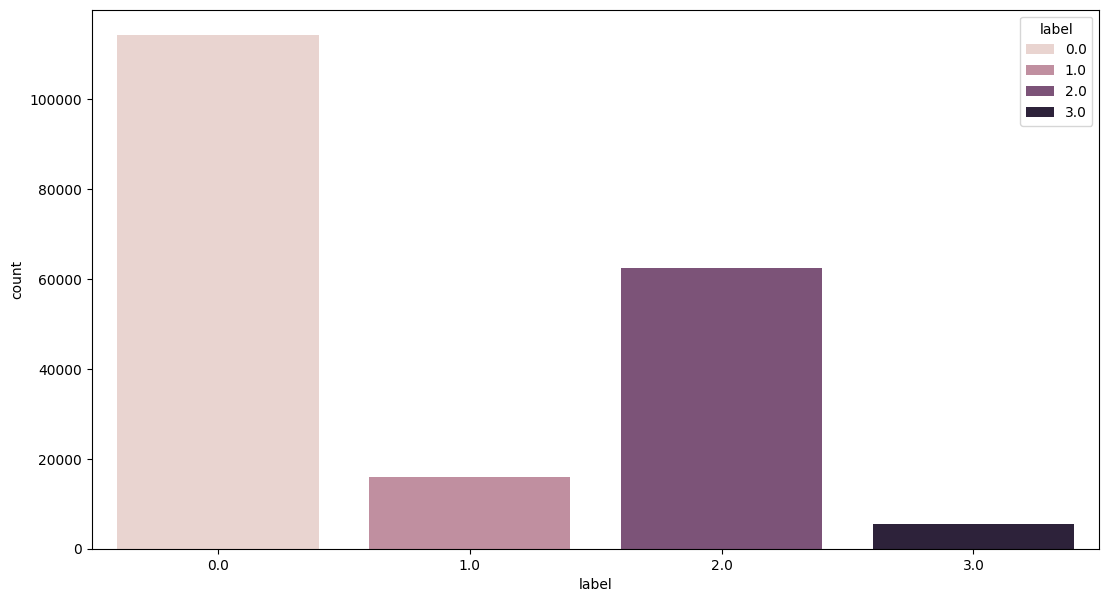
1. massive imbalance
2. 0(>1lkh) >> 2 > 1 >> 3

If we feed this to ml model it'll take path of least resistance hence, Because Label 0.0 and 2.0 make up the vast majority of the data, the model will spend all its time learning how to predict those two and mostly ignore 1.0 and 3.0. it'll guess 0 for every row.. and still achieve over 50% accuracy

In [43]:
# sns.violinplot(x= 'label', y = 'comment_len', data = df)
# sns.boxenplot(x= 'label', y = 'comment_len', data = df)

### Observations: label v/s comment_len 
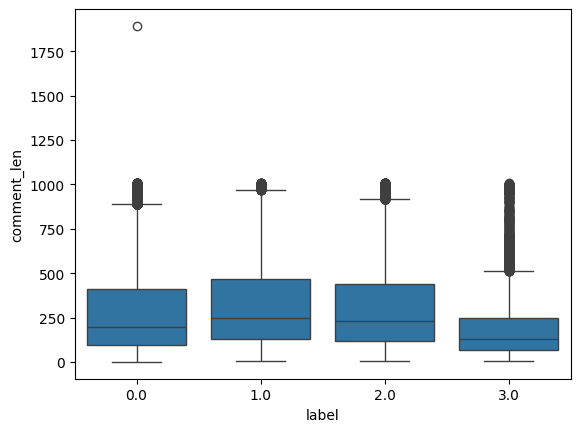
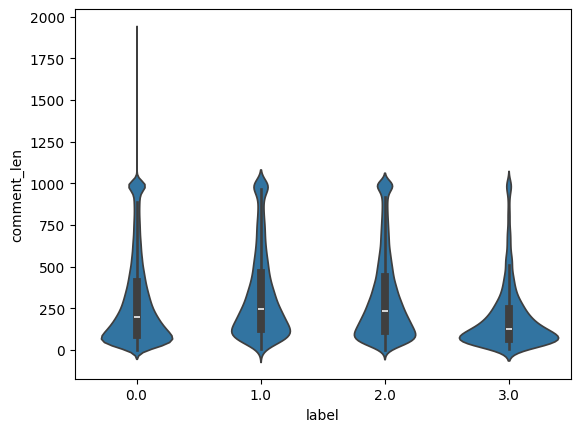
1. we have 1 outlier comment getting 1900~ len even after plateform limit, probably collected due to error in parsing or wasne't cleaned.
2. the higest label has the lowest comment len
3. Since the labels have an invisible sealing of 1000 words it suggests that the platform or API where we got this data from has hard word limit of 1000
4. Lable 3 is odd one out, it's IQR is significantly lower than other 3 
    - whatever comments category label 3 is for people tend to write it short yet there's strangly high volumne of them that push all the way to plateform limit.

1. 1000 word limit
2. The Missing "Middle Ground"
Look at the "neck" of the violin for Label 1.0 and 2.0 (the area between 500 and 900). It is extremely thin. meaning human behavior here is highly polarized. Users either write standard, short-to-medium comments (between 50 and 400 length), OR they go completely unhinged and write a massive wall of text that hits the 1000-character cap. Very few people naturally stop typing at exactly 700 characters.


- The box plot showed us that Label 3.0 was shorter, but this plot shows us how much shorter.
- as seen how wide the base is for Label 3.0 compared to the others. The vast majority of these comments are incredibly brief (likely under 100 characters).
- Despite this, it still has that tiny little bulge at 1000, meaning a small dedicated group is still spamming the max limit even in this category.

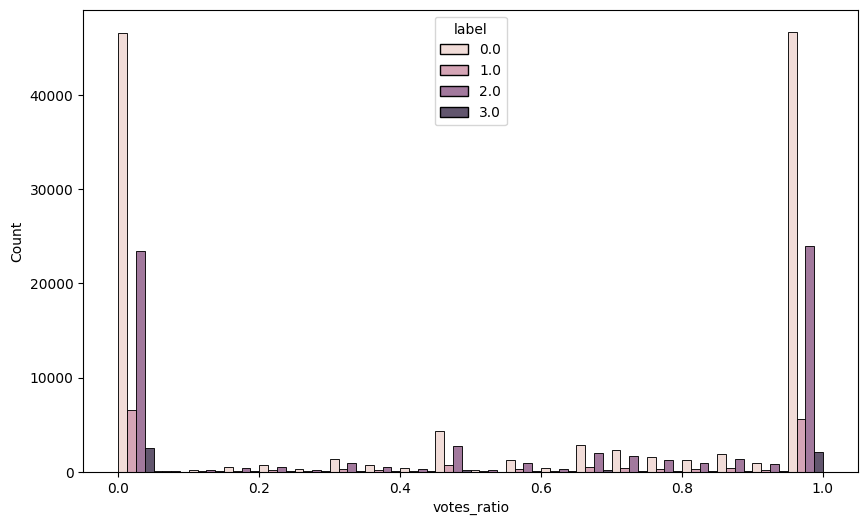

In [44]:
plt.figure(figsize=(10, 6))
# A 1D histogram using hue to separate the labels - great for data clumps across diff labels
sns.histplot(data=df, x='votes_ratio', hue='label', bins=20, multiple='dodge')
plt.show()

<Axes: xlabel='label', ylabel='votes_ratio'>

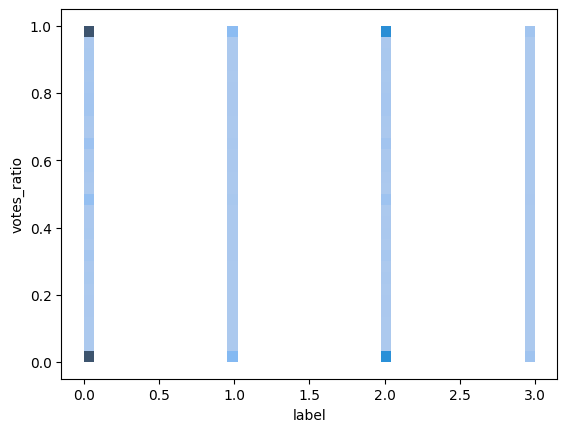

In [45]:
sns.histplot(x= 'label', y = 'votes_ratio', data = df)

### Vote Ratio vs label
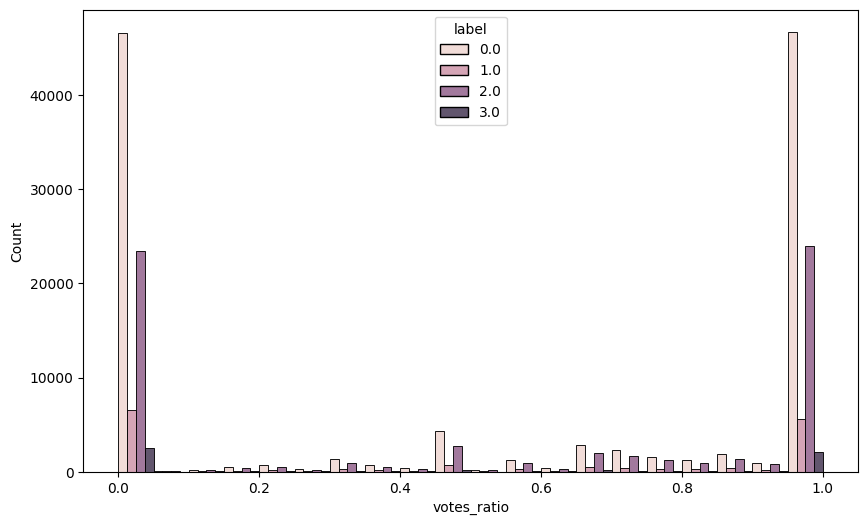
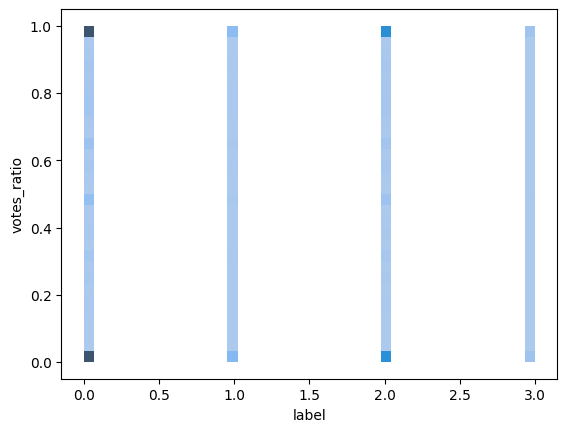
1. the plot is almost uniform 
2. since the vast majority snaps to either 0 or 1 it means there's very huge amount of posts with low engagement (1/0+1=1) 
2. Mini spikes neat 0.5
3. for label 1 and 3 the meadian line is perfectly 0.5 - half of data lean towards 0 or 1
4. for label 0 and 2 the median line is higer ~0.66 the data favors +ve ratios as more than half of data is above 0.5 
5. very few comments have ratios between 0.2-0.5 or 0.8 - This confirms High column votes are rare as 4/4+1 = 0.2 

In [46]:
# sns.boxplot(x='label', y='engagement_score', data=df)
# sns.scatterplot(x='label', y='engagement_score', data=df)

### Engagement Score vs Label
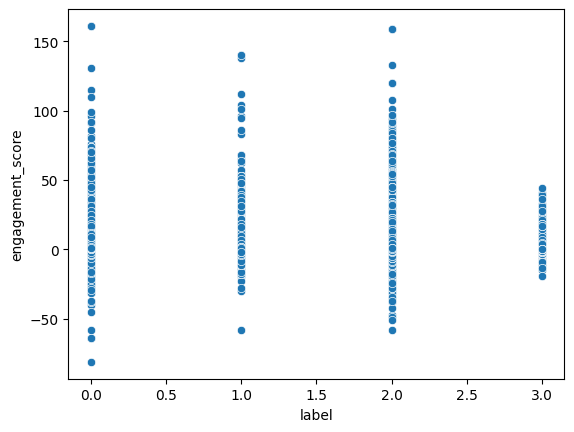
1. data is really skewed
2. vast majority of data is concentrated near zero
3. Have fat tails (heavy outliers)
4. although it's not very clear yet just from the looks it's seems like 
    - label 0 and 2 have the highest amount of +ve engagement
    - label 3.0 is much constrained, lack the wild virality and maxim at around 50

In [47]:
# sns.lineplot(x='engagement_score', y='comment_len', data=df)

### Observations: engagement and comment length
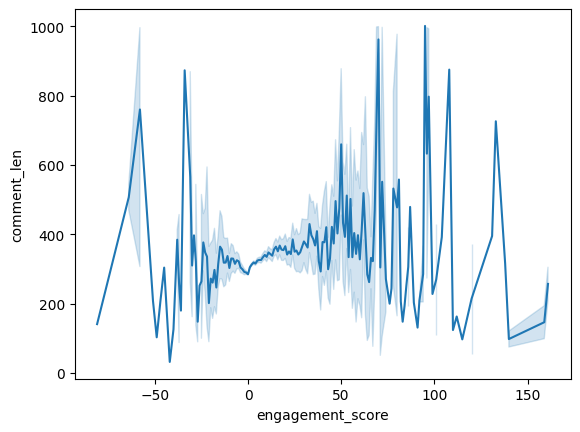
1. there's a stable zone between 0-50 with avg comment length ranging between 300-400
2. below -25 and above +75 thel line starts acting wildly and the shaded area which is the confidence interval(seaborn ~95%) gets very wide meaning there are few pointing at extreme scores, thus it doesn't feel like trend more like outliers
3. Note:
    - Narrow Shading: High confidence. You have enough data to be sure the "average" comment length is actually there.

    - Wide/Erratic Shading: Low confidence. The model is guessing based on very thin evidence.

thus most of the users have an engagement score between 0 and 40, and they typically write comments that are 300–350 characters long. The data outside of that range is too thin to find any conclusions from

In [48]:
# sns.boxplot(x='label', y='num_!', data=df)
# sns.violinplot(x='label', y='num_!', data=df)

In [49]:
# sns.boxplot(x='label', y='num_ques', data=df)

### Emotion Obsevation: num_ques vs label and num_! vs label

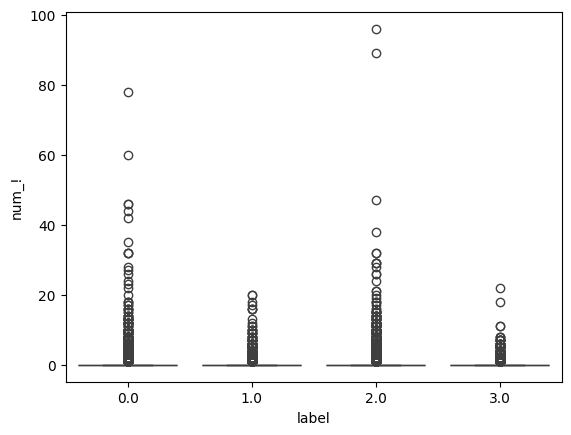
1. they are all sitting on zero, it means at least 75% of all comments in your dataset contain absolutely zero exclamation marks.

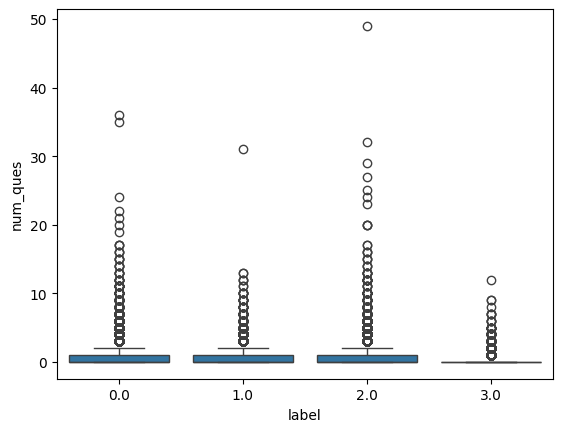

1. The "Punctuation Spammers" (Labels 0.0 and 2.0)

    Just like we saw in the comment length plots, Labels 0.0 and 2.0 are where the extreme behavior lives.

- The Exclamation Outliers: Someone in Label 2.0 used nearly 100 exclamation marks in a single comment! Label 0.0 isn't far behind, hitting around 80.

- The Question Outliers: Similarly, users in Labels 0.0 and 2.0 are dropping up to 50 question marks at a time.

- What this means: These classes contain highly expressive, possibly angry, confused, or spammy comments. This is a fantastic signal for classification.

2. Label 3.0 Remains the Quiet Category and it perfectly with the violin plot from earlier. Label 3.0 had the shortest comments, and here we see they also use the least punctuation. Their exclamation marks cap out around 20, and question marks barely pass 10.

In [50]:
# sns.barplot(data = df, x = 'label', y = 'sentiment_vader', hue='label')
# sns.histplot(data=df, x='sentiment_vader', bins=30, kde=True, color='skyblue')

### Obeservation : Sentiment vs label
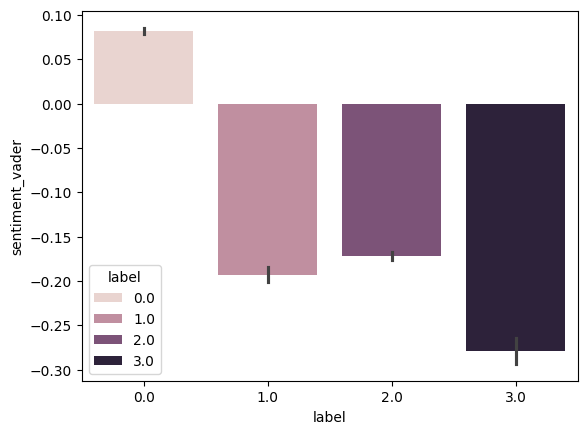
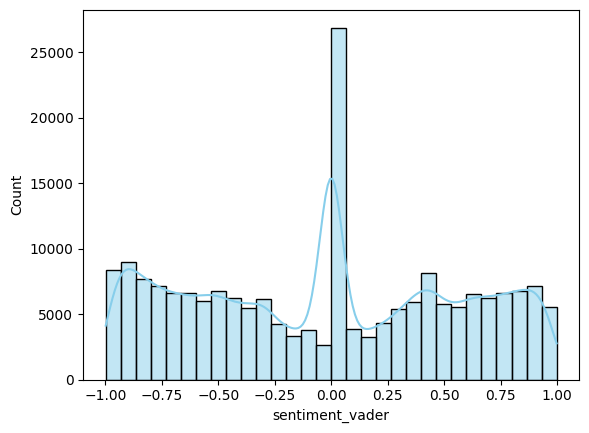
The higest number of comments have a neutral tone to it..
1. The bar for label 0.0 is the only one sitting above the zero line (averaging around +0.08). means comments in this category are generally positive, polite, or constructive
2. label 3 is the Highly Toxic or Angry Class as the bar plunges nearly -28, making it most negative category meaning these comments are likely highly aggressive, containing strong insults, swearing, or intense negative emotion.
3. labels 1.0 and 2.0 both sit around -0.17 to -0.19, 


In [51]:
# sns.countplot(x='created_hour', hue='label', data=df)

### Observations: hour vs label
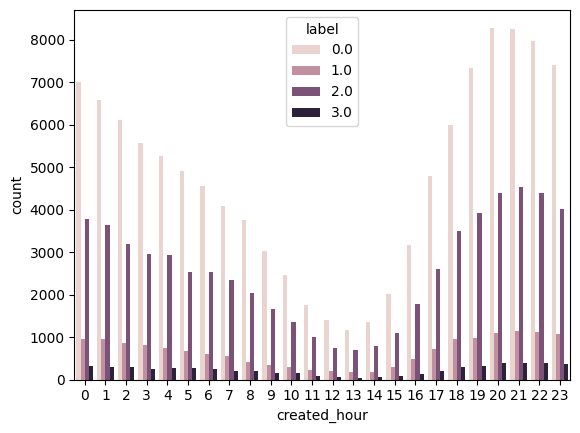
1. **Night Owl Supremacy!** 
2. best timer ranges between 7-9pm and stay high well past midnight
3. most probably users are scrolling and commenting primarily during evening and late night hours..
4. pretty much all the labels follow exact same curve.. means that more comments in the time frame are general - thus won't help much in prediction

In [52]:
# sns.countplot(x='weekday', hue='label', data=df) #0 represents Monday and 6 represents Sunday
# sns.countplot(x='weekend', hue='label', data=df) #0 represents Monday and 6 represents Sunday

### Weekday vs Label
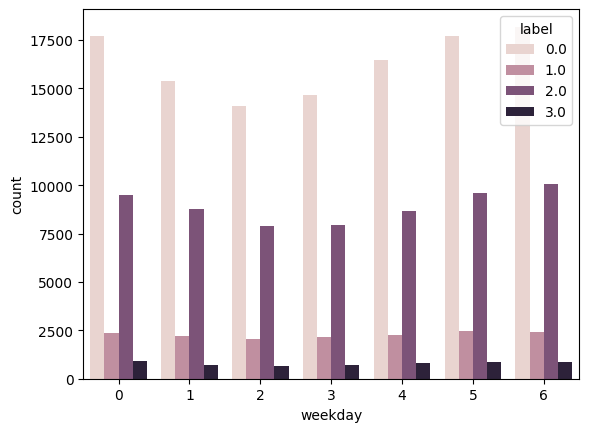
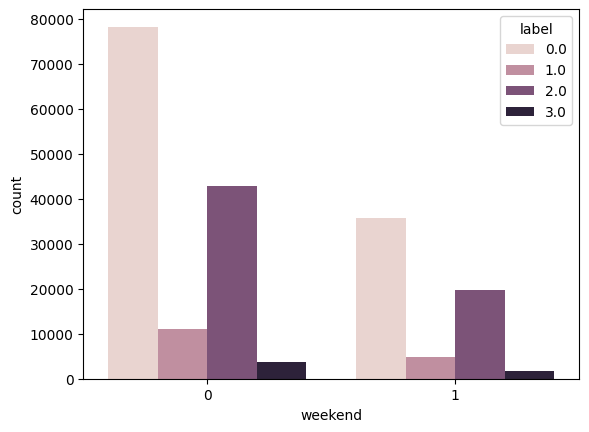

- The Highs: Days 0, 5, and 6 (Monday, Saturday, Sunday) show the highest volume of comments.

- The Lows: Activity distinctly dips in the middle of the week, hitting rock bottom on Day 2 (Wednesday).

- The Insight: Your users are most active on the weekends and immediately at the start of the work/school week, likely dropping off mid-week when they are busiest.

There's a jump from weekend to weekday: sun to mon; people comment more on after weekends

1. The Volume Illusion (5 Days vs. 2 Days)
At first glance, it looks like weekday activity (0) absolutely crushes weekend activity (1), with the bars being roughly twice as high.

- Label 0.0 has about 78,000 comments on weekdays vs. about 36,000 on weekends.

- The Catch: A weekday bucket contains 5 days of data, while the weekend bucket only contains 2 days.

- The Insight: If you divide 78,000 by 5, you get roughly 15,600 comments per day. If you divide 36,000 by 2, you get 18,000 comments per day. Your users are actually more active per day on the weekend! The raw count just looks smaller because it's a shorter time window.

2. The shape of the staircase in bucket 0 is absolutely identical to the shape in bucket 1. The ratios between Labels 0.0, 1.0, 2.0, and 3.0 do not change at all when the weekend hits.

Finale:
The ultimate conclusion from all three plots is that user behavior is incredibly consistent over time. While total traffic goes up and down, the type of comments (the labels) stays perfectly steady.

In [53]:
# pd.crosstab(df['gender'], df['label'], normalize='index').plot(kind='bar', stacked=True)

### Gender vs label
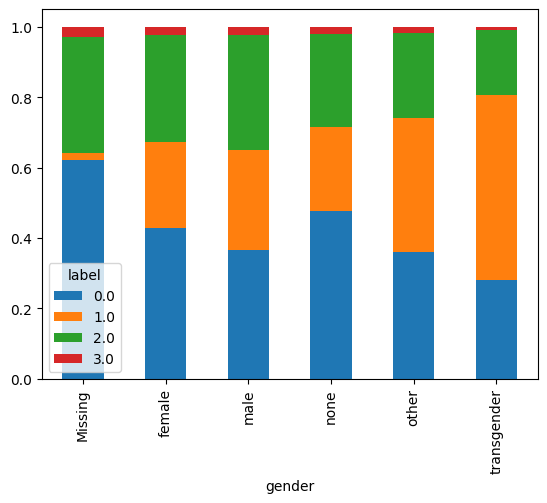

1. missing baseline;; missing is dominated by 0(blue) and 2
2. transgender is dominated by label 1 and least by label 3
3. orange spikes from nothing in missing to taking 25-50% in distribution
    - means: whatever label 1 is its' perhaps identity attack or controversial or specific type of engagement **It's heavily trigged the moment gender identity is involved or even mentioned**

since we have isolated the missing ones in actual final dataset it'd be of help in analysis

<Axes: >

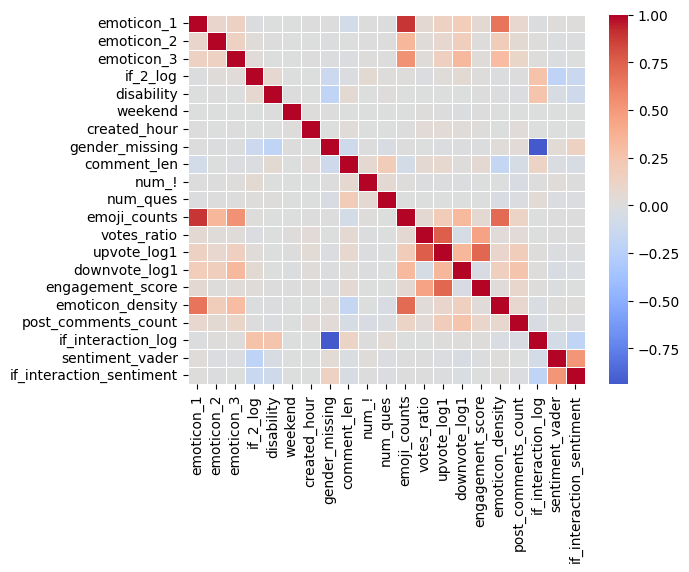

In [54]:
numerical_col = ['emoticon_1', 'emoticon_2', 'emoticon_3', 
                'if_2_log','disability', 'weekend', 'created_hour',
                'gender_missing', 'comment_len',
                'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
                'downvote_log1', 'engagement_score', 'emoticon_density',
                'post_comments_count', 'if_interaction_log',
                'sentiment_vader','if_interaction_sentiment'] #excluded: ['post_id', 'comments'(in tf-idf), word_cnt,'race_missing', 'religion_missing', 'if_1', 'if_2', 'if_1_log']

corr = X_train[numerical_col].corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)

### Heat Map Analysis 
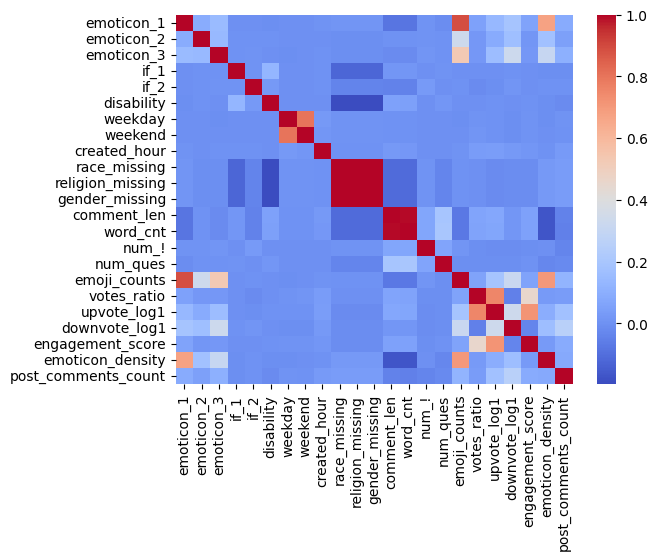
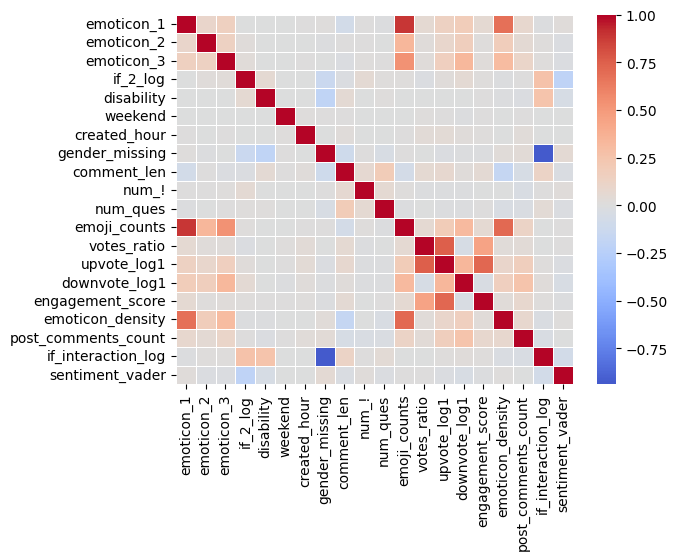
1. The missing data block in the middle, since they're perfectly correlated that means is a user didn't provide their race or any other two[gender, religion] means they didn't provide other 3 as well.. 
    - Keeping all three won't give any new informations, thus keep any 1 and drop other two
2. If you notice *comment_len* and *word_cnt* are almost almost itentical(same gradient) - can drop 1 or 2
    - Also if notice there's a red block in middle: more words -> higer charecter length
    - Drop: *word_cnt* is is better to keep helps with nlp as kinda like tokens
3. Engagement clusters near right bottom - upvote_log1, engagement_score, vote_ratio
    - that means that since engagement scores and ratios are mathematically calculated using the raw upvote/downvote counts, they are highly dependent on each other.
4. correlation between emoticon_1, emoji_counts, and emoticon_density
    - If someone uses a lot of emojis overall (emoji_counts), they naturally have a higher emoticon_density and are highly likely to have triggered whatever specific emoji emoticon_1 represents.
5. As we had guess above *weekend* and *weekday* interset - as we can drop either; drop weekday
6. Since these 'if_1', 'if_2', 'if_1_log', 'if_2_log' and 'if_interaction_log' were heavly correlated so to avoid feature bloating i've decided to keep only 'if_2_log' and 'if_interaction_log'
7. if we notice a blue cell bwt if_interaction_log and sentiment_vader is the only string negative correlation in the matrix rest everything is either red(positive) or white(no relationship). Lgbm already learn the high interaction and negative sentiment is label 3.0 but it'll take 2-3 levels to get so why not create a interation term the encodes the joint patter in single col.(if_interaction_sentiment). The model can now learn that in one split instead of two, which means it needs fewer trees and learns it more reliably.

### Denoting correctly before ML training:

In [55]:
import copy
X_train_split = copy.deepcopy(X_train_final)
X_val_split, y_train_split, y_val_split = copy.deepcopy(X_val_final),copy.deepcopy(y_train),copy.deepcopy(y_val)

In [56]:
unique, counts = np.unique(y_val_split, return_counts=True)
print("\nClass distribution in Validation set:")
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} rows")


Class distribution in Validation set:
Label 0: 22835 rows
Label 1: 3183 rows
Label 2: 12488 rows
Label 3: 1094 rows


## Model Training:

### Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV

# lr = LogisticRegression(max_iter= 1000, class_weight='balanced', C=1.0, n_jobs=-1)

# lr.fit(X_train_split, y_train_split)
# y_pred = lr.predict(X_val_split)

# print(classification_report(y_val_split, y_pred))
# print("f1_sctrore: ", f1_score(y_val_split, y_pred, average='macro'))

In [58]:
# param_grid = {'C': [0.1, 1.0, 5.0]}
# lr_base = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=500)

# print("Starting Lightning-Fast Grid Search...")
# grid_search = GridSearchCV(
#     estimator=lr_base,
#     param_grid=param_grid,
#     scoring='f1_macro', 
#     cv=3,               
#     verbose=3
# )
# grid_search.fit(X_train_final, y_train_split)

In [59]:
# print("\n" + "="*40)
# print(f"Best Parameters Found: {grid_search.best_params_}")
# print("="*40)

# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_val_final)
# print(classification_report(y_val_split, y_pred))

In [60]:
# np.save('train_embeddings.npy', train_text_emb)
# np.save('val_embeddings.npy', val_text_emb)
# np.save('test_embeddings.npy', test_text_emb)

In [61]:
# using lighgm
import lightgbm as lgb
from sklearn.metrics import f1_score, classification_report

# tocsr() is important — LightGBM expects CSR format
X_tr = X_train_split.tocsr()
X_va = X_val_split.tocsr()

In [62]:
import joblib
model = joblib.load('/kaggle/input/datasets/kradarsh04/recent-model/lgbm_final_v2.pkl')

In [63]:
# model = lgb.LGBMClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     num_leaves=127,
#     min_child_samples=20,
#     class_weight={0: 1, 1: 1.2, 2: 1, 3: 6},
#     subsample=0.8,
#     colsample_bytree=0.3,
#     reg_alpha=0.1,
#     n_jobs=-1,
#     random_state=42,
#     verbose=-1
# )
# print("done with model part")
# model.fit(X_tr, y_train_split)
# model.fit(
#     X_tr, y_train_split,
#     eval_set=[(X_va, y_val_split)],
#     callbacks=[
#         lgb.early_stopping(50, verbose=True),
#         lgb.log_evaluation(100)
#     ]
# )
print("done with model.fit part")

preds  = model.predict(X_va)
scores = f1_score(y_val_split, preds, average=None)

print(classification_report(y_val_split, preds))
print(f"Macro F1  : {f1_score(y_val_split, preds, average='macro'):.4f}")
print(f"Class 3 F1: {scores[3]:.4f}")

done with model.fit part


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.78      0.80      0.79      3183
           2       0.87      0.91      0.89     12488
           3       0.69      0.67      0.68      1094

    accuracy                           0.92     39600
   macro avg       0.83      0.83      0.83     39600
weighted avg       0.92      0.92      0.92     39600

Macro F1  : 0.8313
Class 3 F1: 0.6800


In [64]:
# joblib.dump(model, 'lgbm_model.pkl')

In [65]:
X_test_csr = X_test_final.tocsr()

test_preds = model.predict(X_test_csr)
sample['label'] = test_preds
sample.to_csv('submission.csv', index=False)
print("done")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


done


### Hyperparameter tuning 

In [66]:
#hpt - #1
# import optuna
# import lightgbm as lgb
# from sklearn.metrics import f1_score, precision_recall_fscore_support
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective(trial):
#     params = {
#         "n_estimators":      1000,
#         "learning_rate":     0.1,
#         "num_leaves":        trial.suggest_int("num_leaves", 31, 127, step=32),
#         "min_child_samples": trial.suggest_int("min_child_samples", 10, 100, step=10),
#         "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.2, 0.6, step=0.1),
#         "reg_alpha":         trial.suggest_float("reg_alpha", 0.01, 1.0, log=True),
#         "reg_lambda":        trial.suggest_float("reg_lambda", 0.01, 1.0, log=True),
#         "subsample":         trial.suggest_float("subsample", 0.6, 1.0, step=0.1),
#         "subsample_freq":    1,
#         "class_weight":      {0: 1, 1: 1.2, 2: 1, 3: 6},
#         "n_jobs":            -1,
#         "random_state":      42,
#         "verbose":           -1,
#     }

#     model = lgb.LGBMClassifier(**params)
#     model.fit(
#         X_tr, y_train_split,
#         eval_set=[(X_va, y_val_split)],
#         callbacks=[
#             lgb.early_stopping(30, verbose=False),
#             lgb.log_evaluation(-1)
#         ]
#     )

#     preds  = model.predict(X_va)
#     macro  = f1_score(y_val_split, preds, average="macro")
#     c3     = f1_score(y_val_split, preds, average=None)[3]
#     combined = 0.6 * macro + 0.4 * c3

#     trial.set_user_attr("macro_f1",  macro)
#     trial.set_user_attr("class3_f1", c3)
#     trial.set_user_attr("best_iter", model.best_iteration_)

#     # per-trial report
#     prec, rec, f1, _ = precision_recall_fscore_support(y_val_split, preds)
#     print(f"\n{'─'*60}")
#     print(f"  Trial {trial.number:>2}  |  combined: {combined:.4f}")
#     print(f"{'─'*60}")
#     print(f"  {'Class':<10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
#     print(f"  {'─'*42}")
#     for cls in range(4):
#         marker = " ← watch" if cls == 3 else ""
#         print(f"  {cls:<10} {prec[cls]:>10.4f} {rec[cls]:>10.4f} "
#               f"{f1[cls]:>10.4f}{marker}")
#     print(f"  {'─'*42}")
#     print(f"  macro{'':5} {'':>10} {'':>10} {macro:>10.4f}")
#     print(f"  leaves={params['num_leaves']} | "
#           f"min_child={params['min_child_samples']} | "
#           f"col={params['colsample_bytree']:.1f} | "
#           f"α={params['reg_alpha']:.3f} | "
#           f"λ={params['reg_lambda']:.3f} | "
#           f"sub={params['subsample']:.1f} | "
#           f"iters={model.best_iteration_}")
#     print(f"{'─'*60}")

#     return combined

# print("objective fun loaded")

In [67]:
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=20, timeout=18000)

# # ── summary table :
# print("\n" + "="*75)
# print("  FULL STUDY SUMMARY")
# print("="*75)
# print(f"  {'Trial':>6} {'Combined':>10} {'Macro F1':>10} "
#       f"{'Class3 F1':>10} {'Iterations':>11} {'num_leaves':>11}")
# print(f"  {'─'*69}")
# for t in sorted(study.trials, key=lambda x: x.value, reverse=True):
#     marker = " ← BEST" if t.number == study.best_trial.number else ""
#     print(f"  {t.number:>6} {t.value:>10.4f} "
#           f"{t.user_attrs['macro_f1']:>10.4f} "
#           f"{t.user_attrs['class3_f1']:>10.4f} "
#           f"{t.user_attrs['best_iter']:>11} "
#           f"{t.params['num_leaves']:>11}"
#           f"{marker}")
# print(f"\n  Best params: {study.best_trial.params}")
# print("="*75)

# #final: 
# print("starting final.. ")
# best        = study.best_trial
# best_params = best.params
# # scale iters for the lr drop: 0.1 → 0.05 means ×2
# scaled_iters = best.user_attrs["best_iter"] * 2

# final_model = lgb.LGBMClassifier(
#     n_estimators=scaled_iters,
#     learning_rate=0.05,          # lower lr, more trees, better generalisation
#     subsample_freq=1,            # keep fix 1 on final model too
#     **best_params,
#     class_weight={0: 1, 1: 1.2, 2: 1, 3: 6},
#     n_jobs=-1,
#     random_state=42,
#     verbose=-1
# )

# # early stopping on final retrain guarantees exact convergence
# final_model.fit(
#     X_tr, y_train_split,
#     eval_set=[(X_va, y_val_split)],
#     callbacks=[
#         lgb.early_stopping(50, verbose=True),
#         lgb.log_evaluation(100)
#     ]
# )
# print("done with model fit.. ")

# preds  = final_model.predict(X_va)
# scores = f1_score(y_val_split, preds, average=None)
# from sklearn.metrics import classification_report
# print(classification_report(y_val_split, preds))
# print(f"Macro F1  : {f1_score(y_val_split, preds, average='macro'):.4f}")
# print(f"Class 3 F1: {scores[3]:.4f}")

# import joblib
# joblib.dump(final_model, '/kaggle/working/lgbm_hpt_final.pkl')
# print("saved → lgbm_hpt_final.pkl")

In [68]:
# #new hpt before sleep: hpt#2
# import optuna
# import lightgbm as lgb
# import joblib
# from sklearn.metrics import f1_score, precision_recall_fscore_support, classification_report
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# X_tr = X_train_split.tocsr()
# X_va = X_val_split.tocsr()

# # ── objective 
# def objective(trial):
#     params = {
#         "n_estimators":      1000,
#         "learning_rate":     0.1,

#         # narrowed from 63 beat 95 consistently
#         "num_leaves":        trial.suggest_int("num_leaves", 47, 95, step=16),

#         # shifted up — trials 3&4 showed higher values help
#         "min_child_samples": trial.suggest_int("min_child_samples", 40, 120, step=20),

#         # 0.4 winning over 0.5 in earlier trials
#         "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.3, 0.5, step=0.05),

#         "reg_alpha":         trial.suggest_float("reg_alpha", 0.01, 0.5, log=True),
#         "reg_lambda":        trial.suggest_float("reg_lambda", 0.01, 0.7, log=True),
#         "subsample":         trial.suggest_float("subsample", 0.7, 1.0, step=0.1),
#         "subsample_freq":    1,   
#         "class_weight":      {0: 1, 1: 1.2, 2: 1, 3: 6},
#         "n_jobs":            -1,
#         "random_state":      42,
#         "verbose":           -1,
#     }

#     m = lgb.LGBMClassifier(**params)
#     m.fit(
#         X_tr, y_train_split,
#         eval_set=[(X_va, y_val_split)],
#         callbacks=[
#             lgb.early_stopping(30, verbose=False),
#             lgb.log_evaluation(-1)
#         ]
#     )

#     preds    = m.predict(X_va)
#     macro    = f1_score(y_val_split, preds, average="macro")
#     c3       = f1_score(y_val_split, preds, average=None)[3]
#     combined = 0.6 * macro + 0.4 * c3

#     trial.set_user_attr("macro_f1",  macro)
#     trial.set_user_attr("class3_f1", c3)
#     trial.set_user_attr("best_iter", m.best_iteration_)

#     prec, rec, f1, _ = precision_recall_fscore_support(y_val_split, preds)
#     print(f"\n{'─'*62}")
#     print(f"  Trial {trial.number:>2}  |  combined: {combined:.4f}")
#     print(f"{'─'*62}")
#     print(f"  {'Class':<8} {'Precision':>10} {'Recall':>10} {'F1':>10}")
#     print(f"  {'─'*44}")
#     for cls in range(4):
#         tag = "  ← watch" if cls == 3 else ""
#         print(f"  {cls:<8} {prec[cls]:>10.4f} {rec[cls]:>10.4f} {f1[cls]:>10.4f}{tag}")
#     print(f"  {'─'*44}")
#     print(f"  {'macro':<8} {'':>10} {'':>10} {macro:>10.4f}")
#     print(f"  leaves={params['num_leaves']} | "
#           f"min_child={params['min_child_samples']} | "
#           f"col={params['colsample_bytree']:.2f} | "
#           f"α={params['reg_alpha']:.3f} | "
#           f"λ={params['reg_lambda']:.3f} | "
#           f"sub={params['subsample']:.1f} | "
#           f"iters={m.best_iteration_}")
#     print(f"{'─'*62}")

#     return combined

# print("objective function done..")

In [69]:
# # ── run study 
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=20, timeout=32400)  # 9hr hard cap


# # ── summary table 
# print("\n" + "="*72)
# print("  FULL HPT SUMMARY  (sorted by combined score)")
# print("="*72)
# print(f"  {'Trial':>6} {'Combined':>10} {'Macro F1':>10} "
#       f"{'Class3 F1':>10} {'Iters':>8} {'Leaves':>8}")
# print(f"  {'─'*56}")
# for t in sorted(study.trials, key=lambda x: x.value, reverse=True):
#     tag = "  ← BEST" if t.number == study.best_trial.number else ""
#     print(f"  {t.number:>6} {t.value:>10.4f} "
#           f"{t.user_attrs['macro_f1']:>10.4f} "
#           f"{t.user_attrs['class3_f1']:>10.4f} "
#           f"{t.user_attrs['best_iter']:>8} "
#           f"{t.params['num_leaves']:>8}"
#           f"{tag}")
# print(f"\n  Best params : {study.best_trial.params}")
# print(f"  Best iters  : {study.best_trial.user_attrs['best_iter']}")
# print("="*72)


# # ── final retrain 
# best        = study.best_trial
# best_params = best.params

# final_model = lgb.LGBMClassifier(
#     n_estimators=2000,     
#     learning_rate=0.05,  #for better generalisation    
#     subsample_freq=1,
#     **best_params,
#     class_weight={0: 1, 1: 1.2, 2: 1, 3: 6},
#     n_jobs=-1,
#     random_state=42,
#     verbose=-1
# )

# print("\nRetraining final model at lr=0.05 with early stopping...")
# final_model.fit(
#     X_tr, y_train_split,
#     eval_set=[(X_va, y_val_split)],
#     callbacks=[
#         lgb.early_stopping(50, verbose=True),
#         lgb.log_evaluation(100)
#     ]
# )

# # ── final evaluation 
# preds  = final_model.predict(X_va)
# scores = f1_score(y_val_split, preds, average=None)

# print("\n" + "="*55)
# print("  FINAL MODEL RESULTS")
# print("="*55)
# print(classification_report(y_val_split, preds))
# print(f"  Macro F1  : {f1_score(y_val_split, preds, average='macro'):.4f}")
# print(f"  Class 3 F1: {scores[3]:.4f}")
# print("="*55)

# # ── save
# joblib.dump(final_model, '/kaggle/working/lgbm_final_v2.pkl')
# print("\nSaved → /kaggle/working/lgbm_final_v2.pkl")

In [70]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import make_scorer, f1_score

# param_grid = {
#     "C": [1.0, 2.0, 3.0],
#     "solver": ["saga"],
#     "class_weight": [
#         "balanced",
#         {0:1, 1:1.2, 2:1, 3:3},
#         {0:1, 1:1.2, 2:1, 3:4}
#     ]
# }

# lr = LogisticRegression(
#     max_iter=1000,
#     solver="saga",
#     C=2.0,
#     class_weight={0:1, 1:1.2, 2:1, 3:3},
#     n_jobs=-1
# )

# grid = GridSearchCV(
#     lr,
#     param_grid=param_grid,
#     scoring=make_scorer(f1_score, average="macro"),
#     cv=3,
#     n_jobs=-1,
#     verbose=2
# )


In [71]:
# grid.fit(X_train_final, y_train)
# print(grid.best_params_)
# best_lr = grid.best_estimator_

# y_pred = best_lr.predict(X_val_final)

In [72]:
# print(classification_report(y_val, y_pred))
# print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

In [73]:
# import joblib

# # 'best_lr' is the variable where you stored your best estimator
# model_filename = 'logistic_regression_model.joblib'

# # Save the model to the Kaggle working directory
# joblib.dump(best_lr, model_filename)

# print(f"Model saved successfully as {model_filename}")

In [74]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, f1_score

# lr = LogisticRegression(
#     max_iter=3000,
#     class_weight="balanced",
#     C=2.0,
#     n_jobs=-1
# )

# lr.fit(X_train_final, y_train)
# y_pred = lr.predict(X_val_final)

# print(classification_report(y_val, y_pred))
# print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

In [75]:
# param_distributions = {
#     'C': loguniform(1e-2, 1e2), 
#     'solver': ['lbfgs'], 
#     'max_iter': [500] 
# }
# lr_base = LogisticRegression(class_weight='balanced', n_jobs=-1)

In [76]:
# random_search = RandomizedSearchCV(
#     estimator=lr_base,
#     param_distributions=param_distributions,
#     n_iter=500,
#     scoring='f1_macro',
#     cv=3,
#     verbose=2,
#     random_state=42,
#     n_jobs=1  
# )

In [77]:
# random_search.fit(X_train_split, y_train_split)

In [78]:
# print(f"Best Macro F1 Score (Cross-Validated): {random_search.best_score_:.4f}")
# print(f"Best Parameters: {random_search.best_params_}")

In [79]:
# best_lr = random_search.best_estimator_
# y_pred_tuned = best_lr.predict(X_val_final)
# from sklearn.metrics import classification_report
# print(classification_report(y_val_split, y_pred_tuned))

In [80]:
# for final submission : same as we trained : TF-IDF + encoded + numerical
# all of which already done in: X_test_final

# test_preds = lr.predict(X_test_final)
# sample['label'] = test_preds
# sample.to_csv('submission.csv', index=False)

### **Miscellaneous**

In [81]:
df.head()

df_train.head()
df_train.tail()

df_test.shape
sample.shape
print(df_train.shape)

print(df_test.columns)
print(len(df_test.columns))

df_train['label'].value_counts()
df_train.head(10)

# from sklearn.dummy import DummyClassifier
# x_train = train.drop(columns = ["label"])
# y_train = train['label']

# dummy = DummyClassifier(strategy='most_frequent')
# dummy.fit(x_train, y_train)

# prediction = dummy.predict(test)
# prediction

#dummg submission
# sample['label']= prediction
# sample.to_csv("submission.csv", index = False)

# sample

# milestone-1 Ques
df_train.shape

objects = df_train.select_dtypes(include='object').columns
len(objects)


numerical_objs = df_train.select_dtypes(include=['int64', 'float64']).columns
len(numerical_objs)

null_vals = df_train.columns[df_train.isna().any()].tolist()
null_vals

num_classes = df_train['label'].nunique()
print(num_classes)
print(df_train['if_2'].min())

#@title Milestone-2

df_train.columns
df_train.head()

# created_date -> datetime
pd.to_datetime(df_train["created_date"]).value_counts() #we got "may(05)"

# df_train.iloc[:, 2:5]
df_train["total_emoticons"] = df_train.iloc[:, 2:5].sum(axis = 1)

df_train["total_emoticons"].max()

# train.loc[(train["label"]==3), "comment"].len().median() #only works when using .str
df_train.loc[(df_train["label"]==3), "comment"].str.len().median()

# prev val of upvote ==10
# train[train["upvote"]==10]

# min-max normalisation -> x-min/max-min 
min_ = df_train['upvote'].min()
max_ = df_train['upvote'].max()
# display(min_, max_)
# df_train["upvote"] = (df_train["upvote"] - min_)/(max_-min_)
# since we already want for upvote 10 we'll do it directly
print((10- min_)/(max_-min_))

df_train.loc[(df_train["label"]==1), "comment"].str.split().str.len().mean()

len(df_train[df_train["comment"].str.contains("Trump", case = False, na = False)])

df_train.head()

words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']


sentence = df_train["comment"][0].split()
print(sentence)
m = len(sentence)
for i in sentence:
    if i in words: m-=1
    else:print(i)
print(m)

tokens = df_train["comment"].str.lower().str.split().explode().nunique()
tokens

# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidr = TfidfVectorizer(stop_words = 'english', min_df = 5, ngram_range= (1,2))


# tfidr_mat = tfidr.fit_transform(df_train['comment'].fillna(''))
# print(len(tfidr_mat.get_feature_names_out()))

# df_train.columns

# Milestone 3

x = df_train.drop(columns=['label']).copy()
y = df_train['label'].astype(int).copy()
# x,y
x_train, x_vald, y_train, y_vald = train_test_split(
    x,y,test_size = 0.20, stratify=y, random_state= 42
)
a, b = x_train.shape
c,d = x_vald.shape
a,b,c,d,a+c

def extract_date(df):
    df = df.copy()
    df['created_date'] = pd.to_datetime(df['created_date'])
    df["day"] = df['created_date'].dt.day.fillna(0).astype(int)
    df["month"] = df['created_date'].dt.month.fillna(0).astype(int)
    df["year"] = df['created_date'].dt.year.fillna(0).astype(int)
    return df
x_train = extract_date(x_train)
x_vald = extract_date(x_vald)
# x_train, x_vald
display(x_train['month'].mode().iloc[0])



(198000, 16)
Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'is_train'],
      dtype='object')
15
4
3
0.04975124378109453
['She', 'might', 'be', 'a', 'bright', 'spot', 'for', 'a', 'party', 'keou', 'on', 'Oahu', 'dominated', 'by', 'greedy', 'criminals', 'or', 'ethically', 'challenged', 'individuals.']
She
might
bright
spot
party
keou
Oahu
dominated
greedy
criminals
ethically
challenged
individuals.
13


np.int64(5)